<a href="https://colab.research.google.com/github/jollyoli93/KnowYourLoadExactly/blob/main/Crane_Detector_RegressionModel_GridSearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Startup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# %cd /content/drive/MyDrive/Crane-Detector/Image_Classes

In [3]:
# import pickle
# with open("cropped_images.pkl", "rb") as f:
#     data = pickle.load(f)

In [4]:

# data['rebar'][0][1]

In [5]:
import numpy as np
import torch
import itertools
import pandas as pd
import matplotlib.pyplot as plt

## Regression Algo

In [6]:
from pathlib import Path
from pandas import DataFrame

In [7]:
train_labels = "/content/drive/MyDrive/Crane-Detector/YOLOv8 Normal/K_Fold/train/2026-01-26_5-Fold_Cross-val/split_4/train/labels"
valid_labels = "/content/drive/MyDrive/Crane-Detector/YOLOv8 Normal/K_Fold/train/2026-01-26_5-Fold_Cross-val/split_4/val/labels"

In [8]:
coord = [p for p in Path(train_labels).glob("*")]

In [9]:
# coord

In [10]:
# print(coord[2])

In [11]:
# with open(coord, "r") as f:
#   coord = f.readlines()
#   print(coord)
#   get_pairs(coord)

### Get Pairs

In [12]:
yolo_txt = [1, 0.48534666666666665, 0.2776875, 0.005231666666666667, 0.013035]


In [13]:
from math import sqrt

def dist_between_centroids(input, target):
  x1, y1 = input
  x2, y2 = target

  dx = x1 - x2
  dy = y1 - y2

  distance = sqrt(dx**2 + dy**2)
  return distance

In [14]:
dist_between_centroids(yolo_txt[1:3], (0.4, 0.16))

0.14537675593904653

In [15]:
# def find_distance(input, target):
#   input_centroid = find_centroid(input)
#   target_centroid = find_centroid(target)

#   distance = dist_between_centroids(input_centroid, target_centroid)
#   return distance


In [16]:
from math import sqrt

def get_pairs(coords):
    coord_split = [
        [float(x) for x in line.strip().split()]
        for line in coords
        if line.strip()
    ]

    hooks = [d for d in coord_split if d[0] == 0]  # hook
    loads = [d for d in coord_split if d[0] == 1]  # load

    pairs = {'hook': [], 'load': []}
    used_hooks = set()

    for load in loads:
        xc_load, yc_load = load[1], load[2]
        h_load = load[-1]
        closest = None
        closest_idx = -1
        min_dist = float("inf")

        for i, hook in enumerate(hooks):
            if i in used_hooks:
                continue

            xc_hook, yc_hook = hook[1], hook[2]

            yt_load = yc_load - (h_load /2)
            yb_hook = yc_hook + hook[-1]/2 #Location at bottom of hook

            # Hook must be above load
            if yb_hook > yt_load:
                continue

            # Horizontal closeness
            dist = abs(xc_load - xc_hook)
            if dist < min_dist:
                min_dist = dist
                closest = hook
                closest_idx = i

        if closest is not None:
            xc, yc, w, h = closest[1:5]
            # aspect = w / h if h != 0 else 0.0
            # area = w*h
            yb = yc + (h / 2)
            #dist = sqrt((xc - xc_load)**2 + (yc - yc_load)**2). feading load dims to features might create shortcut/memorisations

            # # get relative offsets normalised
            dx = (xc_load - xc) /w
            dy = (yc_load - yb) /h

            pairs['hook'].append(
                [xc, yc, w, h] + [yb]
            )
            pairs['load'].append([dx, dy])

            used_hooks.add(closest_idx)

    return pairs


In [17]:
test_path = "/content/drive/MyDrive/Crane-Detector/YOLOv8 Normal/K_Fold/train/labels/2502070850004013_jpg.rf.f506ae5a132097aaa38096eaa9fb83ad.txt"

In [18]:
test = get_pairs(open(test_path).readlines())

In [19]:
test

{'hook': [[0.5130966666666666,
   0.1705575,
   0.003871666666666667,
   0.0191775,
   0.18014625],
  [0.11253166666666668, 0.0072025, 0.01004, 0.01393, 0.0141675]],
 'load': [[-0.6108480413258589, 2.590861686872638],
  [1.1998671978751643, 5.0608399138549895]]}

## Create Dataset

In [20]:
from torch.utils.data import Dataset

class YoloLabelsDataset(Dataset):
    def __init__(self, label_dir):
        self.label_dir = label_dir
        self.labels = list(Path(label_dir).glob("*.txt"))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label = self.labels[idx]

        with open(label, "r") as f:
          coord_file = f.readlines()

        pairs = get_pairs(coord_file)

        if (pairs is None or
            'hook' not in pairs or 'load' not in pairs or
            len(pairs['hook']) == 0 or len(pairs['load']) == 0):
            return None
        return pairs

In [21]:
train_ds = YoloLabelsDataset(train_labels)
valid_ds = YoloLabelsDataset(valid_labels)

In [22]:
len(train_ds), len(valid_ds)

(322, 80)

In [23]:
train_ds.labels[2]

PosixPath('/content/drive/MyDrive/Crane-Detector/YOLOv8 Normal/K_Fold/train/2026-01-26_5-Fold_Cross-val/split_4/train/labels/2502070850004013_jpg.rf.f506ae5a132097aaa38096eaa9fb83ad.txt')

In [24]:
test_data = train_ds.__getitem__(2)

In [25]:
batch = next(iter(train_ds))

In [26]:
test_valid_data = valid_ds.__getitem__(6)

## Get scalars for normalising the offsets


In [27]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Collect all data for fitting
train_feats = []
train_targets = []

for label_file in Path(train_labels).glob("*.txt"):
    with open(label_file) as f:
        pairs = get_pairs(f.readlines())
        if pairs:
            train_feats.extend(pairs['hook'])
            train_targets.extend(pairs['load'])

# Fit the scalers
feat_scaler = StandardScaler().fit(train_feats)
target_scaler = StandardScaler().fit(train_targets)

In [28]:
feat_scaler.mean_, target_scaler.mean_

(array([0.52705581, 0.27860506, 0.02611817, 0.05749599, 0.30735305]),
 array([-0.20133916,  3.33621179]))

## Collate Function

In [29]:
def collate_pairs(batch, feat_scale, target_scale):
    batch = [item for item in batch if item is not None]

    xs = []
    ys = []

    for item in batch:
        for x_coords, y_coords in zip(item['hook'], item['load']):
            if(len(x_coords)==0 or len(y_coords)==0):
              continue

            xs.append(x_coords)
            ys.append(y_coords)

    if len(xs) == 0:
      return None

    xs_scaled = feat_scale.transform(xs)
    ys_scaled = target_scale.transform(ys)

    x_tens = torch.tensor(xs_scaled, dtype=torch.float32)
    y_tens = torch.tensor(ys_scaled, dtype=torch.float32)

    return x_tens, y_tens



In [30]:
collate_pairs([test_data], feat_scaler, target_scaler)

(tensor([[-0.0700, -0.6104, -0.4513, -1.1552, -0.7060],
         [-2.0782, -1.5332, -0.3262, -1.3134, -1.6273]]),
 tensor([[-0.0947, -0.1904],
         [ 0.3242,  0.4406]]))

## Create Dataloaders

In [31]:
torch.manual_seed(42)

In [32]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_ds, batch_size=332, collate_fn=lambda b: collate_pairs(b, feat_scaler, target_scaler), shuffle=True)
valid_dataloader = DataLoader(valid_ds, batch_size=80, collate_fn=lambda b: collate_pairs(b, feat_scaler, target_scaler), shuffle=True)

In [33]:
batch = next(iter(train_dataloader))

In [34]:
x, y = batch

In [35]:
x.shape, y.shape

(torch.Size([310, 5]), torch.Size([310, 2]))

In [36]:
# batch = next(iter(valid_dataloader))
# x, y = batch
# x.shape, y.shape

# Define Test Model

In [ ]:
class LinearRegression(torch.nn.Module):
    def __init__(self, in_feat, out_feat) -> None:
        super().__init__()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(in_feat, 100),
            torch.nn.ReLU(),
            torch.nn.Linear(100, 100),
            torch.nn.ReLU(),
            torch.nn.Linear(100, out_feat),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.linear(x)
        return x

linearModel = LinearRegression(5, 2)

optimizer = torch.optim.SGD(linearModel.parameters(), lr=0.1, momentum=0.9)
loss = torch.nn.MSELoss()

In [ ]:
linearModel = LinearRegression(5, 2)

In [ ]:
optimizer = torch.optim.SGD(linearModel.parameters(), lr=0.1, momentum=0.9)
loss = torch.nn.MSELoss()

In [ ]:
def train_epoch(dataloader, optim, loss_fn, model):
  for i, batch in enumerate(dataloader):
    x,y = batch

    # add jitter to the model
    if model.training:
        x = x + (torch.randn_like(x) * 0.005)
        print(x.shape)
    predict = model(x)
    loss = loss_fn(predict, y)
    optim.zero_grad()
    loss.backward()
    optim.step()
  return loss.item()

In [ ]:
# train_epoch(train_dataloader, optimizer, loss, linearModel)

In [ ]:
# len(valid_dataloader.dataset)

In [ ]:
from sklearn.metrics import r2_score

@torch.no_grad()
def validate_epoch(dataloader, model, loss_fn):
  total_loss = 0
  all_targets = []
  all_preds = []

  for i, batch in enumerate(dataloader):
    x, y = batch
    predict = model(x)
    print(f"y {y[0]} - predict {predict[0]}")
    loss = loss_fn(predict, y)
    total_loss += loss.item()

    all_preds.append(predict.cpu())
    all_targets.append(y.cpu())

  all_preds = torch.cat(all_preds, dim=0).numpy()
  all_targets = torch.cat(all_targets, dim=0).numpy()

  # Compute r2
  r2 = r2_score(all_targets, all_preds)
  avg_loss = total_loss / len(dataloader.dataset)

  return avg_loss, r2


In [ ]:
# validate_epoch(valid_dataloader, linearModel, loss)

In [ ]:
def fit(epochs):
  train_losses = []
  valid_losses = []
  rsqrd = []

  for i in range(1, epochs+1):
    train_loss = train_epoch(train_dataloader, optimizer, loss, linearModel)
    valid_loss = validate_epoch(valid_dataloader, linearModel, loss)
    mse, r2 = valid_loss

    train_losses.append(train_loss)
    valid_losses.append(mse)
    rsqrd.append(r2)

    print(f"Epoch {i}- Train Loss: {train_loss} - Valid Loss: {mse} -  R2 Loss: {r2}")
  return train_losses, valid_losses, rsqrd

In [ ]:
epochs =10

metrics = fit(epochs)

torch.Size([310, 5])
y tensor([-0.0627, -0.4285]) - predict tensor([0.5276, 0.5084])
Epoch 1- Train Loss: 1.278900384902954 - Valid Loss: 0.04335780739784241 -  R2 Loss: -0.07621103525161743
torch.Size([310, 5])
y tensor([-0.0627, -0.4285]) - predict tensor([0.4966, 0.4751])
Epoch 2- Train Loss: 1.2666044235229492 - Valid Loss: 0.0432016909122467 -  R2 Loss: -0.0698128342628479
torch.Size([310, 5])
y tensor([-0.0627, -0.4285]) - predict tensor([0.4538, 0.4293])
Epoch 3- Train Loss: 1.2443695068359375 - Valid Loss: 0.04300247132778168 -  R2 Loss: -0.06146591901779175
torch.Size([310, 5])
y tensor([-0.0627, -0.4285]) - predict tensor([0.4021, 0.3745])
Epoch 4- Train Loss: 1.2149385213851929 - Valid Loss: 0.042783507704734804 -  R2 Loss: -0.05199509859085083
torch.Size([310, 5])
y tensor([-0.0627, -0.4285]) - predict tensor([0.3422, 0.3120])
Epoch 5- Train Loss: 1.1810792684555054 - Valid Loss: 0.04256442487239838 -  R2 Loss: -0.04201924800872803
torch.Size([310, 5])
y tensor([-0.0627, -0

In [ ]:
metrics

([1.278900384902954,
  1.2666044235229492,
  1.2443695068359375,
  1.2149385213851929,
  1.1810792684555054,
  1.1452280282974243,
  1.1095386743545532,
  1.0761618614196777,
  1.047481656074524,
  1.024701476097107],
 [0.04335780739784241,
  0.0432016909122467,
  0.04300247132778168,
  0.042783507704734804,
  0.04256442487239838,
  0.04236021041870117,
  0.042183947563171384,
  0.042044425010681154,
  0.041947707533836365,
  0.04188939929008484],
 [-0.07621103525161743,
  -0.0698128342628479,
  -0.06146591901779175,
  -0.05199509859085083,
  -0.04201924800872803,
  -0.03212183713912964,
  -0.02280259132385254,
  -0.014460325241088867,
  -0.007532596588134766,
  -0.0022510886192321777])

### Plot graphs


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
train_losses, valid_losses, rsqrd = metrics

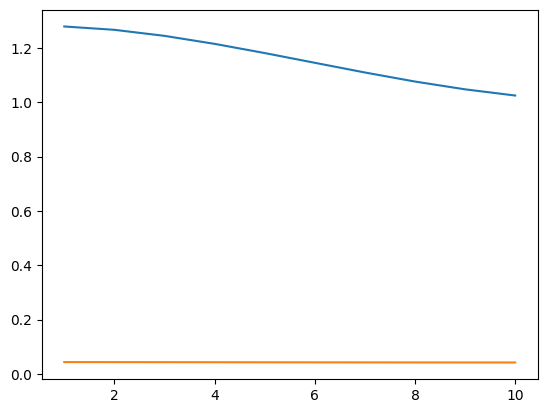

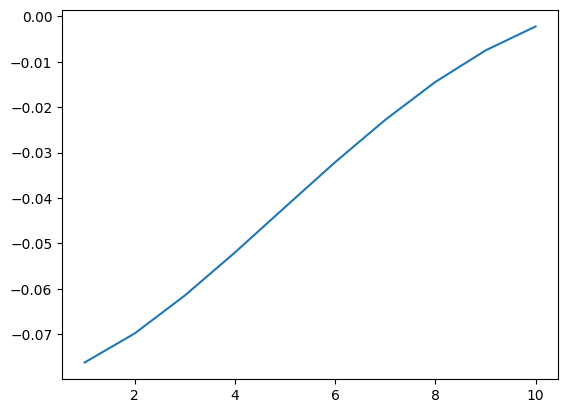

In [ ]:
plt.plot(range(1, epochs+1), train_losses)
plt.plot(range(1, epochs+1), valid_losses)
plt.show()
plt.plot(range(1, epochs+1), rsqrd)
plt.show()

In [ ]:
rsqrd

[-0.07621103525161743,
 -0.0698128342628479,
 -0.06146591901779175,
 -0.05199509859085083,
 -0.04201924800872803,
 -0.03212183713912964,
 -0.02280259132385254,
 -0.014460325241088867,
 -0.007532596588134766,
 -0.0022510886192321777]

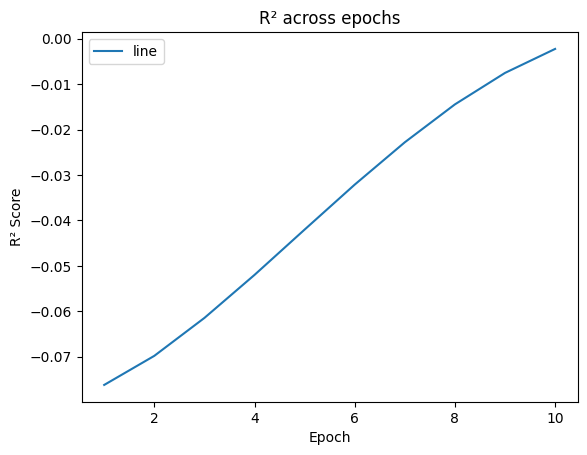

In [ ]:
fig, ax = plt.subplots()
ax.set_title("R\u00b2 across epochs")
# ax.grid(True)
ax.set_ylabel("R\u00b2 Score")
ax.set_xlabel("Epoch")
ax.plot(range(1, 11), rsqrd, label="line")
ax.legend()

# Experimental Training

## Define Training Loops

In [37]:
class LinearRegression(torch.nn.Module):
    def __init__(self, in_feat, out_feat, hidden) -> None:
        super().__init__()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(in_feat, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, out_feat),
        )

    def forward(self, x):
        x = self.linear(x)
        return x

In [38]:
import torch
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

class CoordCropModel:
    def __init__(self, model, opt_class, loss, dataloaders, lr=0.1, device=None, momentum=0.9, debug=False) -> None:
        self.model = model
        self.loss_fn = loss
        self.train_dl = dataloaders['train']
        self.valid_dl = dataloaders['valid']
        self.lr = lr
        self.momentum = momentum
        self.debug = debug

        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        if opt_class == torch.optim.Adam:
          self.opt = opt_class(self.model.parameters(), lr=self.lr)
        else:
            self.opt = torch.optim.SGD(self.model.parameters(), lr=self.lr, momentum=self.momentum)

        self.train_loss = []
        self.valid_loss = []
        self.r2 = []
        self.epochs = 0

    def train_epoch(self):
        self.model.train()
        epoch_loss = 0.0
        batches_process = 0

        for data in self.train_dl:
          if data is None:
            print("No data")
            continue
          x, y, = data

          if self.model.training:
            x = x + (torch.randn_like(x) * 0.005)

          x, y = x.to(self.device), y.to(self.device)

          predict = self.model(x)
          loss = self.loss_fn(predict, y)

          self.opt.zero_grad()
          loss.backward()

          #DEBUG - Check weights
          if self.debug == True:
            for name, param in self.model.named_parameters():
              if param.grad is not None:
                  print(f"debug {name} grad norm:", param.grad.abs().sum().item())
              else:
                print("Grads are blank")

          self.opt.step()
          epoch_loss += loss.item()

          batches_process += 1

        if batches_process > 0:
          self.train_loss.append(epoch_loss / batches_process if batches_process > 0 else 0)

    @torch.no_grad()
    def validate_epoch(self):
        self.model.eval()
        total_loss = 0.0
        all_targets, all_preds = [], []
        batches_process = 0

        for data in self.valid_dl:
          if data is None:
            print("No data")
            continue
          x, y = data
          x, y = x.to(self.device), y.to(self.device)
          predict = self.model(x)
          loss = self.loss_fn(predict, y)
          total_loss += loss.item()

          all_preds.append(predict.cpu())
          all_targets.append(y.cpu())
          batches_process += 1

        all_preds = torch.cat(all_preds, dim=0).numpy()
        all_targets = torch.cat(all_targets, dim=0).numpy()

        ## Prevent NaN/Inf errors when inversing transform
        if np.isnan(all_preds).any() or np.isinf(all_preds).any():
            print("Warning: NaNs or Infs detected in predictions!")
            self.r2.append(-999.0)
            self.valid_loss.append(999.0)
            return

        # Convert back to original values
        preds = target_scaler.inverse_transform(all_preds)
        targs = target_scaler.inverse_transform(all_targets)
        r2 = r2_score(targs, preds)


        self.r2.append(r2)
        self.valid_loss.append(total_loss / batches_process if batches_process > 0 else 0)

    def fit(self, epochs, print_metrics=True):
      self.epochs += epochs

      for i in range(1, epochs+1):
          self.train_epoch()
          self.validate_epoch()

          if print_metrics:
            print(f"Epoch {i} - "
                  f"Train Loss: {self.train_loss[-1]:.4f} - "
                  f"Valid Loss: {self.valid_loss[-1]:.4f} - "
                  f"R2: {self.r2[-1]:.4f}")

    def get_loss_graph(self, title="", legend="upper right"):
      fig, ax = plt.subplots()
      ax.set_title(f"Loss across epochs {title}")

      ax.set_ylabel("Loss")
      ax.set_xlabel("Epoch")

      (p1,) = ax.plot(range(1, self.epochs+1), self.train_loss, linestyle="-", label="Training Loss")
      (p2,) = ax.plot(range(1, self.epochs+1), self.valid_loss, linestyle="--", label="Validation Loss")
      ax.legend(loc=legend)

    def get_r2_graph(self, title=""):
      fig, ax = plt.subplots()
      ax.set_title(f"R\u00b2 across epochs {title}")
      ax.set_ylabel("R\u00b2 Score")
      ax.set_xlabel("Epoch")
      ax.plot(range(1, self.epochs+1), self.r2)

    def metrics(self):
      metrics = self.train_loss, self.valid_loss, self.r2
      return metrics

In [39]:
len(train_ds), len(valid_ds)

(322, 80)

In [40]:
from torch.utils.data import DataLoader

seed = 42

g = torch.Generator()
g.manual_seed(seed)

train_dataloader = DataLoader(
    train_ds,
    batch_size=len(train_ds),
    collate_fn=lambda b: collate_pairs(b, feat_scaler, target_scaler),
    shuffle=True,
    generator=g,
    drop_last=True
)

valid_dataloader = DataLoader(
    valid_ds,
    batch_size=len(train_ds),
    collate_fn=lambda b: collate_pairs(b, feat_scaler, target_scaler),
    shuffle=False,
    generator=g,
    drop_last=False
)

In [41]:
dataloader_dict = {'train': train_dataloader, 'valid': valid_dataloader}

## Test Training Loop

In [42]:
batch = dataloader_dict['train']

In [43]:
loss = torch.nn.MSELoss()
opt = torch.optim.SGD
LinearBasic = LinearRegression(5, 2, 100) # 5 features output x,y

cropModel1 = CoordCropModel(model=LinearBasic, loss=loss, opt_class=opt, dataloaders=dataloader_dict, lr=0.0005)

In [44]:
cropModel1.fit(5)

Epoch 1 - Train Loss: 0.9923 - Valid Loss: 3.3074 - R2: 0.0082
Epoch 2 - Train Loss: 0.9921 - Valid Loss: 3.3073 - R2: 0.0083
Epoch 3 - Train Loss: 0.9919 - Valid Loss: 3.3071 - R2: 0.0085
Epoch 4 - Train Loss: 0.9916 - Valid Loss: 3.3068 - R2: 0.0087
Epoch 5 - Train Loss: 0.9912 - Valid Loss: 3.3065 - R2: 0.0090


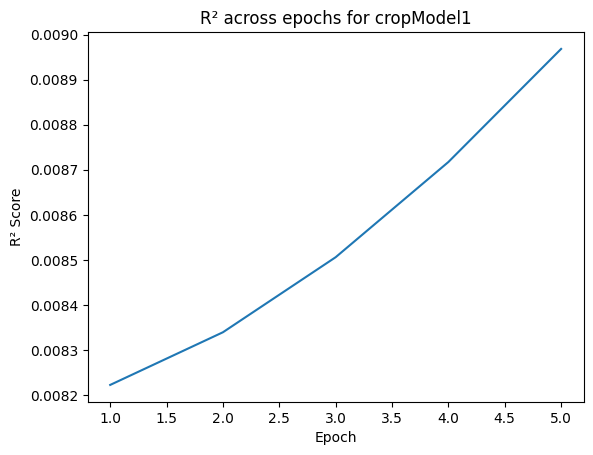

In [45]:
cropModel1.get_r2_graph("for cropModel1")

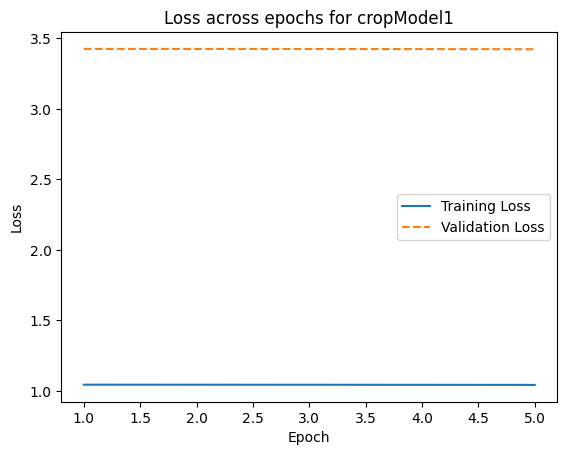

In [ ]:
cropModel1.get_loss_graph("for cropModel1", legend="center right")


In [ ]:
huber_loss = torch.nn.HuberLoss()
opt = torch.optim.Adam
Linear64 = LinearRegression(5, 2, 100) # 5 features output x,y

cropModel1 = CoordCropModel(model=Linear64, loss=huber_loss, opt_class=opt, dataloaders=dataloader_dict, lr=0.0005)

## Grid Search through parameters

### SGD

In [ ]:
param_grid = {
    'lr': [0.1, 0.01, 0.001],
    'momentum' : [0.0, 0.5, 0.9],
    'loss' : [torch.nn.MSELoss(), torch.nn.HuberLoss()],
    'hidden_layer':[10, 50, 100, 200]
}

In [ ]:
keys, values = zip(*param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

records = []

for i, params in enumerate(experiments):
    print(f"\n--- Running Trial {i+1}/{len(experiments)}: {params} ---")

    model = LinearRegression(5, 2, params['hidden_layer'])

    runner = CoordCropModel(
        model=model,
        loss=params['loss'],
        dataloaders=dataloader_dict,
        lr=params['lr'],
        opt_class='SGD',
        momentum=params['momentum']
    )

    try:
      runner.fit(15, print_metrics=False)

      records.append({
          **params,
          'opt_name': 'SGD',
          'final_train_loss': runner.train_loss[-1],
          'final_valid_loss': runner.valid_loss[-1],
          'final_r2': runner.r2[-1],
          'best_r2': max(runner.r2)
      })

    except Exception as e:
            print(f"Trial {i+1} failed at training with error: {e}")
            continue


--- Running Trial 1/72: {'lr': 0.1, 'momentum': 0.0, 'loss': MSELoss(), 'hidden_layer': 10} ---

--- Running Trial 2/72: {'lr': 0.1, 'momentum': 0.0, 'loss': MSELoss(), 'hidden_layer': 50} ---

--- Running Trial 3/72: {'lr': 0.1, 'momentum': 0.0, 'loss': MSELoss(), 'hidden_layer': 100} ---

--- Running Trial 4/72: {'lr': 0.1, 'momentum': 0.0, 'loss': MSELoss(), 'hidden_layer': 200} ---

--- Running Trial 5/72: {'lr': 0.1, 'momentum': 0.0, 'loss': HuberLoss(), 'hidden_layer': 10} ---

--- Running Trial 6/72: {'lr': 0.1, 'momentum': 0.0, 'loss': HuberLoss(), 'hidden_layer': 50} ---

--- Running Trial 7/72: {'lr': 0.1, 'momentum': 0.0, 'loss': HuberLoss(), 'hidden_layer': 100} ---

--- Running Trial 8/72: {'lr': 0.1, 'momentum': 0.0, 'loss': HuberLoss(), 'hidden_layer': 200} ---

--- Running Trial 9/72: {'lr': 0.1, 'momentum': 0.5, 'loss': MSELoss(), 'hidden_layer': 10} ---

--- Running Trial 10/72: {'lr': 0.1, 'momentum': 0.5, 'loss': MSELoss(), 'hidden_layer': 50} ---

--- Running Tria

In [ ]:
results_df = pd.DataFrame(records)

In [ ]:
results_df

,lr,momentum,loss,hidden_layer,opt_name,final_train_loss,final_valid_loss,final_r2,best_r2
0,0.100,0.0,MSELoss(),10,SGD,0.979857,3.343336,0.006766,0.006766
1,0.100,0.0,MSELoss(),50,SGD,0.893302,3.191021,0.080228,0.080228
2,0.100,0.0,MSELoss(),100,SGD,0.835408,3.176441,0.097324,0.097324
3,0.100,0.0,MSELoss(),200,SGD,0.778061,3.041456,0.155540,0.155540
4,0.100,0.0,HuberLoss(),10,SGD,0.161894,0.270371,-0.020478,-0.020478
...,...,...,...,...,...,...,...,...,...
67,0.001,0.9,MSELoss(),200,SGD,0.976414,3.340768,0.011965,0.011965
68,0.001,0.9,HuberLoss(),10,SGD,0.165006,0.271732,-0.021676,-0.021676
69,0.001,0.9,HuberLoss(),50,SGD,0.175562,0.288585,-0.043726,-0.043726
70,0.001,0.9,HuberLoss(),100,SGD,0.170957,0.282899,-0.004351,-0.004351


In [ ]:
results_df.sort_values(by='final_r2', ascending=False)

,lr,momentum,loss,hidden_layer,opt_name,final_train_loss,final_valid_loss,final_r2,best_r2
19,0.100,0.9,MSELoss(),200,SGD,0.712533,2.918259,0.234943,0.234943
18,0.100,0.9,MSELoss(),100,SGD,0.718601,2.977663,0.223312,0.223312
17,0.100,0.9,MSELoss(),50,SGD,0.741238,2.928226,0.207864,0.207864
11,0.100,0.5,MSELoss(),200,SGD,0.733922,2.988452,0.192585,0.192585
3,0.100,0.0,MSELoss(),200,SGD,0.778061,3.041456,0.155540,0.155540
...,...,...,...,...,...,...,...,...,...
56,0.001,0.5,MSELoss(),10,SGD,1.061696,3.590661,-0.045895,-0.045895
29,0.010,0.0,HuberLoss(),50,SGD,0.174267,0.283418,-0.046798,-0.046798
60,0.001,0.5,HuberLoss(),10,SGD,0.168975,0.278920,-0.049653,-0.049653
54,0.001,0.0,HuberLoss(),100,SGD,0.168857,0.275268,-0.050433,-0.050433


In [ ]:
best_trial = results_df.sort_values(by='final_r2', ascending=False).iloc[0]

In [ ]:
best_trial

,19
lr,0.1
momentum,0.9
loss,MSELoss()
hidden_layer,200
opt_name,SGD
final_train_loss,0.712533
final_valid_loss,2.918259
final_r2,0.234943
best_r2,0.234943


In [ ]:
results_df.to_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/GridSearch/sgd_01")

#### Run Best SGD

In [ ]:
best = records[19]

In [ ]:
best['hidden_layer']

200

In [ ]:
bestSGD = LinearRegression(5, 2, 200) # 5 features output x,y

bestSgdModel = CoordCropModel(model=bestSGD, loss=torch.nn.MSELoss(), opt_class='SGD', dataloaders=dataloader_dict, lr=0.1)

In [ ]:
bestSgdModel.fit(100)

Epoch 1 - Train Loss: 1.0186 - Valid Loss: 3.3640 - R2: 0.0054
Epoch 2 - Train Loss: 0.9752 - Valid Loss: 3.2598 - R2: 0.0452
Epoch 3 - Train Loss: 0.9244 - Valid Loss: 3.1766 - R2: 0.0790
Epoch 4 - Train Loss: 0.8844 - Valid Loss: 3.1258 - R2: 0.1030
Epoch 5 - Train Loss: 0.8545 - Valid Loss: 3.0992 - R2: 0.1188
Epoch 6 - Train Loss: 0.8389 - Valid Loss: 3.0771 - R2: 0.1325
Epoch 7 - Train Loss: 0.8337 - Valid Loss: 3.0315 - R2: 0.1535
Epoch 8 - Train Loss: 0.8183 - Valid Loss: 2.9629 - R2: 0.1799
Epoch 9 - Train Loss: 0.7918 - Valid Loss: 2.9062 - R2: 0.1999
Epoch 10 - Train Loss: 0.7714 - Valid Loss: 2.8849 - R2: 0.2079
Epoch 11 - Train Loss: 0.7610 - Valid Loss: 2.8974 - R2: 0.2084
Epoch 12 - Train Loss: 0.7484 - Valid Loss: 2.9268 - R2: 0.2085
Epoch 13 - Train Loss: 0.7341 - Valid Loss: 2.9506 - R2: 0.2128
Epoch 14 - Train Loss: 0.7221 - Valid Loss: 2.9547 - R2: 0.2212
Epoch 15 - Train Loss: 0.7138 - Valid Loss: 2.9410 - R2: 0.2297
Epoch 16 - Train Loss: 0.7086 - Valid Loss: 2.919

(None, None)

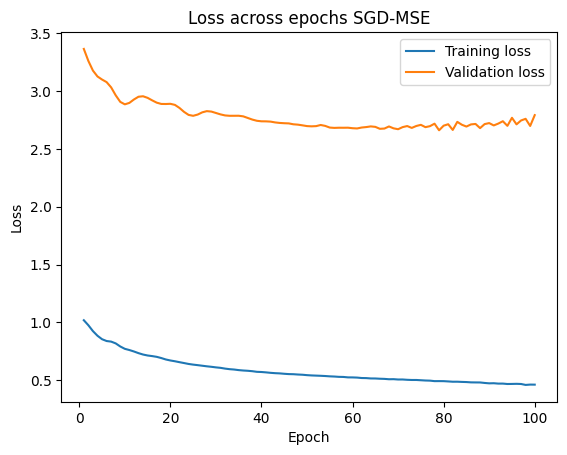

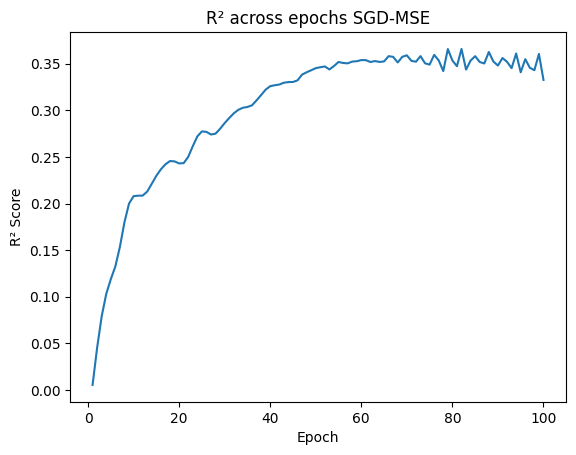

In [ ]:
bestSgdModel.get_loss_graph("SGD-MSE"), bestSgdModel.get_r2_graph("SGD-MSE")

#### Run Best Huber SGD

In [ ]:
huber100Sgd = LinearRegression(5, 2, 200)

huber100SgdModel = CoordCropModel(
    model=huber100Sgd,
    loss=torch.nn.HuberLoss(),
    opt_class='SGD',
    dataloaders=dataloader_dict,
    lr=0.1
    )

huber100SgdModel.fit(100)

Epoch 1 - Train Loss: 0.1673 - Valid Loss: 0.2730 - R2: -0.0134
Epoch 2 - Train Loss: 0.1612 - Valid Loss: 0.2664 - R2: -0.0084
Epoch 3 - Train Loss: 0.1551 - Valid Loss: 0.2627 - R2: -0.0041
Epoch 4 - Train Loss: 0.1527 - Valid Loss: 0.2606 - R2: 0.0042
Epoch 5 - Train Loss: 0.1513 - Valid Loss: 0.2578 - R2: 0.0203
Epoch 6 - Train Loss: 0.1478 - Valid Loss: 0.2547 - R2: 0.0417
Epoch 7 - Train Loss: 0.1430 - Valid Loss: 0.2535 - R2: 0.0621
Epoch 8 - Train Loss: 0.1404 - Valid Loss: 0.2545 - R2: 0.0777
Epoch 9 - Train Loss: 0.1409 - Valid Loss: 0.2553 - R2: 0.0883
Epoch 10 - Train Loss: 0.1418 - Valid Loss: 0.2541 - R2: 0.0957
Epoch 11 - Train Loss: 0.1409 - Valid Loss: 0.2515 - R2: 0.1000
Epoch 12 - Train Loss: 0.1387 - Valid Loss: 0.2492 - R2: 0.1007
Epoch 13 - Train Loss: 0.1371 - Valid Loss: 0.2480 - R2: 0.0995
Epoch 14 - Train Loss: 0.1367 - Valid Loss: 0.2470 - R2: 0.0994
Epoch 15 - Train Loss: 0.1363 - Valid Loss: 0.2455 - R2: 0.1025
Epoch 16 - Train Loss: 0.1348 - Valid Loss: 0.

(None, None)

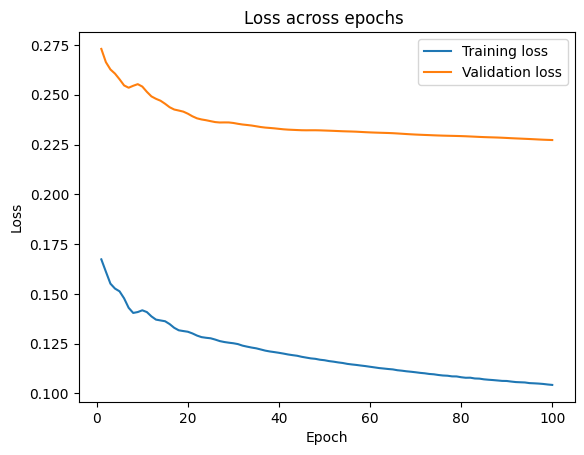

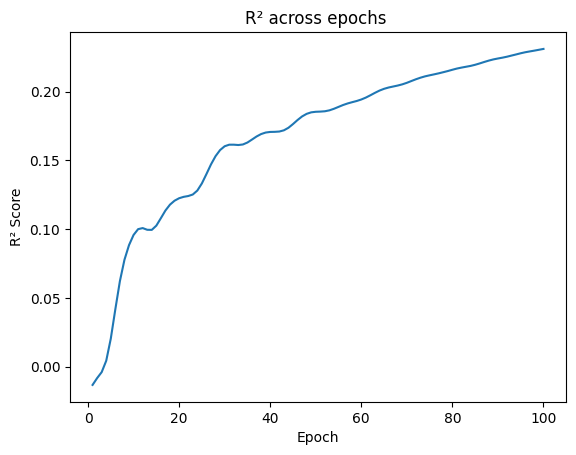

In [ ]:
huber100SgdModel.get_loss_graph("SGD-Huber"), huber100SgdModel.get_r2_graph("SGD-Huber")

In [ ]:
trn1, valid1, r21 = bestSgdModel.metrics()
trn2, valid2, r22 = huber100SgdModel.metrics()

In [ ]:
sdg = {"train":trn1, "valid":valid1, "r2":r21}

In [ ]:
sdgMse = pd.DataFrame(sdg); sdgMse.to_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/results/sdgMse.csv")

In [ ]:
sgdH = {"train":trn2, "valid":valid2, "r2":r22}
sdgHuber = pd.DataFrame(sgdH)
sdgHuber.to_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/results/sdgHuber.csv")

### Adam

In [ ]:
param_grid = {
    'lr': [0.01, 0.005, 0.001], #crashing at 0.1 and 0.0005
    'loss' : [torch.nn.MSELoss(), torch.nn.HuberLoss()],
    'opt_class': [torch.optim.Adam],
    'hidden_layer':[50, 100, 200, 250]
}

In [ ]:
keys, values = zip(*param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

records = []

for i, params in enumerate(experiments):
    print(f"\n--- Running Trial {i+1}/{len(experiments)}: {params} ---")

    model = LinearRegression(5, 2, params['hidden_layer'])

    runner = CoordCropModel(
        model=model,
        loss=params['loss'],
        dataloaders=dataloader_dict,
        lr=params['lr'],
        opt_class=params['opt_class']
    )

    try:
      runner.fit(20, print_metrics=True) #increase epochs for dur to lower LRs

      records.append({
          **params,
          'opt_name': runner.opt,
          'final_train_loss': runner.train_loss[-1],
          'final_valid_loss': runner.valid_loss[-1],
          'final_r2': runner.r2[-1],
          'best_r2': max(runner.r2)
      })

    except Exception as e:
            print(f"Trial {i+1} failed at training with error: {e}")
            continue


--- Running Trial 1/24: {'lr': 0.01, 'loss': MSELoss(), 'opt_class': <class 'torch.optim.adam.Adam'>, 'hidden_layer': 50} ---
Epoch 1 - Train Loss: 0.9875 - Valid Loss: 3.2267 - R2: 0.0614
Epoch 2 - Train Loss: 0.9122 - Valid Loss: 3.1038 - R2: 0.1010
Epoch 3 - Train Loss: 0.8756 - Valid Loss: 3.0462 - R2: 0.1252
Epoch 4 - Train Loss: 0.8463 - Valid Loss: 3.0238 - R2: 0.1444
Epoch 5 - Train Loss: 0.8182 - Valid Loss: 3.0202 - R2: 0.1600
Epoch 6 - Train Loss: 0.7951 - Valid Loss: 3.0083 - R2: 0.1752
Epoch 7 - Train Loss: 0.7778 - Valid Loss: 2.9639 - R2: 0.1932
Epoch 8 - Train Loss: 0.7595 - Valid Loss: 2.9073 - R2: 0.2100
Epoch 9 - Train Loss: 0.7430 - Valid Loss: 2.8677 - R2: 0.2221
Epoch 10 - Train Loss: 0.7310 - Valid Loss: 2.8449 - R2: 0.2340
Epoch 11 - Train Loss: 0.7182 - Valid Loss: 2.8344 - R2: 0.2469
Epoch 12 - Train Loss: 0.7064 - Valid Loss: 2.8343 - R2: 0.2567
Epoch 13 - Train Loss: 0.6986 - Valid Loss: 2.8404 - R2: 0.2602
Epoch 14 - Train Loss: 0.6930 - Valid Loss: 2.8448

In [ ]:
results_df_adam = pd.DataFrame(records)

In [ ]:
results_df_adam

,lr,loss,opt_class,hidden_layer,opt_name,final_train_loss,final_valid_loss,final_r2,best_r2
0,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,50,Adam (\nParameter Group 0\n amsgrad: False\...,0.647299,2.831560,0.265061,0.273091
1,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,100,Adam (\nParameter Group 0\n amsgrad: False\...,0.592126,2.764668,0.302930,0.311706
2,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,200,Adam (\nParameter Group 0\n amsgrad: False\...,0.651904,2.844493,0.280336,0.280336
3,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,250,Adam (\nParameter Group 0\n amsgrad: False\...,0.643105,2.752165,0.292221,0.295746
4,0.010,HuberLoss(),<class 'torch.optim.adam.Adam'>,50,Adam (\nParameter Group 0\n amsgrad: False\...,0.108651,0.229052,0.237889,0.237889
5,0.010,HuberLoss(),<class 'torch.optim.adam.Adam'>,100,Adam (\nParameter Group 0\n amsgrad: False\...,0.112946,0.227715,0.228534,0.228534
6,0.010,HuberLoss(),<class 'torch.optim.adam.Adam'>,200,Adam (\nParameter Group 0\n amsgrad: False\...,0.113286,0.228054,0.231953,0.231953
7,0.010,HuberLoss(),<class 'torch.optim.adam.Adam'>,250,Adam (\nParameter Group 0\n amsgrad: False\...,0.116966,0.234711,0.216913,0.216913
8,0.005,MSELoss(),<class 'torch.optim.adam.Adam'>,50,Adam (\nParameter Group 0\n amsgrad: False\...,0.728023,2.950019,0.208002,0.208002
9,0.005,MSELoss(),<class 'torch.optim.adam.Adam'>,100,Adam (\nParameter Group 0\n amsgrad: False\...,0.646080,2.779883,0.284279,0.284279


In [ ]:
results_df_adam.to_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/GridSearch/adam_01")

In [ ]:
best_trial_adam = results_df_adam.sort_values(by='final_r2', ascending=False); best_trial_adam

,lr,loss,opt_class,hidden_layer,opt_name,final_train_loss,final_valid_loss,final_r2,best_r2
1,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,100,Adam (\nParameter Group 0\n amsgrad: False\...,0.592126,2.764668,0.302930,0.311706
10,0.005,MSELoss(),<class 'torch.optim.adam.Adam'>,200,Adam (\nParameter Group 0\n amsgrad: False\...,0.616063,2.748846,0.302919,0.302919
3,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,250,Adam (\nParameter Group 0\n amsgrad: False\...,0.643105,2.752165,0.292221,0.295746
9,0.005,MSELoss(),<class 'torch.optim.adam.Adam'>,100,Adam (\nParameter Group 0\n amsgrad: False\...,0.646080,2.779883,0.284279,0.284279
11,0.005,MSELoss(),<class 'torch.optim.adam.Adam'>,250,Adam (\nParameter Group 0\n amsgrad: False\...,0.623593,2.806084,0.281328,0.281328
2,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,200,Adam (\nParameter Group 0\n amsgrad: False\...,0.651904,2.844493,0.280336,0.280336
0,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,50,Adam (\nParameter Group 0\n amsgrad: False\...,0.647299,2.831560,0.265061,0.273091
15,0.005,HuberLoss(),<class 'torch.optim.adam.Adam'>,250,Adam (\nParameter Group 0\n amsgrad: False\...,0.107156,0.226315,0.241270,0.241270
4,0.010,HuberLoss(),<class 'torch.optim.adam.Adam'>,50,Adam (\nParameter Group 0\n amsgrad: False\...,0.108651,0.229052,0.237889,0.237889
6,0.010,HuberLoss(),<class 'torch.optim.adam.Adam'>,200,Adam (\nParameter Group 0\n amsgrad: False\...,0.113286,0.228054,0.231953,0.231953


In [ ]:
best_trial_adam = results_df_adam.sort_values(by='final_r2', ascending=False).iloc[0:3]; best_trial_adam

,lr,loss,opt_class,hidden_layer,opt_name,final_train_loss,final_valid_loss,final_r2,best_r2
1,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,100,Adam (\nParameter Group 0\n amsgrad: False\...,0.592126,2.764668,0.302930,0.311706
10,0.005,MSELoss(),<class 'torch.optim.adam.Adam'>,200,Adam (\nParameter Group 0\n amsgrad: False\...,0.616063,2.748846,0.302919,0.302919
3,0.010,MSELoss(),<class 'torch.optim.adam.Adam'>,250,Adam (\nParameter Group 0\n amsgrad: False\...,0.643105,2.752165,0.292221,0.295746


In [ ]:
best_trial_adam_huber = (
    results_df_adam[results_df_adam['loss'].astype(str).str.contains('HuberLoss')]
    .sort_values(by='final_r2', ascending=False)
    .iloc[0:3]
)

best_trial_adam_huber

,lr,loss,opt_class,hidden_layer,opt_name,final_train_loss,final_valid_loss,final_r2,best_r2
15,0.005,HuberLoss(),<class 'torch.optim.adam.Adam'>,250,Adam (\nParameter Group 0\n amsgrad: False\...,0.107156,0.226315,0.241270,0.241270
4,0.010,HuberLoss(),<class 'torch.optim.adam.Adam'>,50,Adam (\nParameter Group 0\n amsgrad: False\...,0.108651,0.229052,0.237889,0.237889
6,0.010,HuberLoss(),<class 'torch.optim.adam.Adam'>,200,Adam (\nParameter Group 0\n amsgrad: False\...,0.113286,0.228054,0.231953,0.231953


#### Run best Adam (MSE)

In [ ]:
mse100 = LinearRegression(5, 2, 100) # 5 features output x,y

mse100Model = CoordCropModel(
    model=mse100,
    loss=torch.nn.MSELoss(),
    opt_class=torch.optim.Adam,
    dataloaders=dataloader_dict,
    lr=0.01
    )
mse100Model.fit(100)

Epoch 1 - Train Loss: 0.9947 - Valid Loss: 3.1455 - R2: 0.0903
Epoch 2 - Train Loss: 0.8988 - Valid Loss: 3.1695 - R2: 0.1020
Epoch 3 - Train Loss: 0.8775 - Valid Loss: 3.0729 - R2: 0.1468
Epoch 4 - Train Loss: 0.8183 - Valid Loss: 2.9678 - R2: 0.1838
Epoch 5 - Train Loss: 0.7745 - Valid Loss: 2.9283 - R2: 0.1957
Epoch 6 - Train Loss: 0.7580 - Valid Loss: 2.9144 - R2: 0.2083
Epoch 7 - Train Loss: 0.7313 - Valid Loss: 2.9106 - R2: 0.2247
Epoch 8 - Train Loss: 0.7118 - Valid Loss: 2.9018 - R2: 0.2363
Epoch 9 - Train Loss: 0.7021 - Valid Loss: 2.8688 - R2: 0.2445
Epoch 10 - Train Loss: 0.6841 - Valid Loss: 2.8180 - R2: 0.2548
Epoch 11 - Train Loss: 0.6713 - Valid Loss: 2.7580 - R2: 0.2747
Epoch 12 - Train Loss: 0.6632 - Valid Loss: 2.7347 - R2: 0.2866
Epoch 13 - Train Loss: 0.6550 - Valid Loss: 2.7580 - R2: 0.2837
Epoch 14 - Train Loss: 0.6427 - Valid Loss: 2.8051 - R2: 0.2727
Epoch 15 - Train Loss: 0.6317 - Valid Loss: 2.8294 - R2: 0.2714
Epoch 16 - Train Loss: 0.6248 - Valid Loss: 2.817

(None, None)

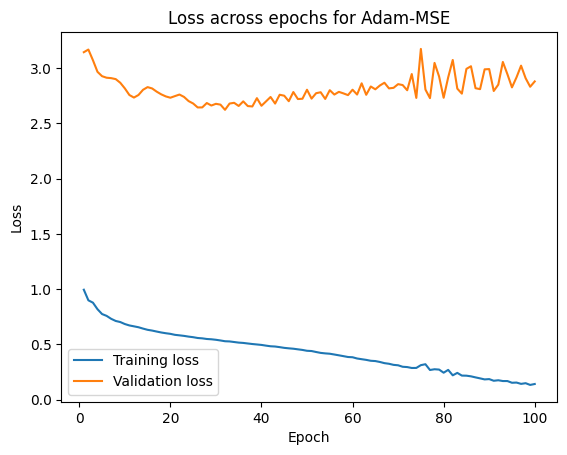

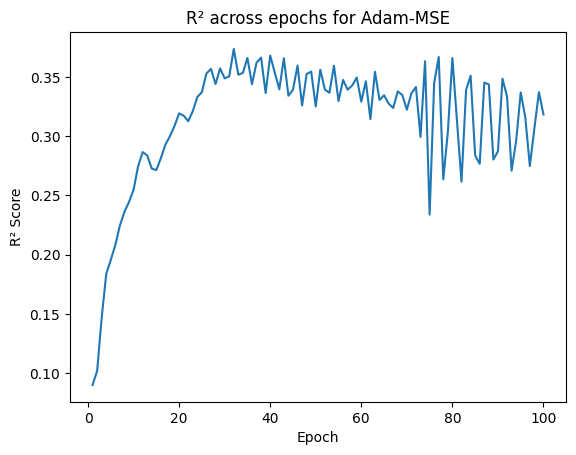

In [ ]:
mse100Model.get_loss_graph("for Adam-MSE"), mse100Model.get_r2_graph("for Adam-MSE")

In [ ]:
trn1, valid1, r21 = mse100Model.metrics()

metrics = {"train":trn1, "valid":valid1, "r2":r21}
metricsDF = pd.DataFrame(metrics)
metricsDF.to_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/results/AdamMSE.csv")

#### Run best Adam (HuberLoss)

In [ ]:
adam250 = LinearRegression(5, 2, 250) # 5 features output x,y

adam250Model = CoordCropModel(
    model=adam250,
    loss=torch.nn.HuberLoss(),
    opt_class=torch.optim.Adam,
    dataloaders=dataloader_dict,
    lr=0.005
    )
adam250Model.fit(100)

Epoch 1 - Train Loss: 0.1596 - Valid Loss: 0.3811 - R2: -0.0956
Epoch 2 - Train Loss: 0.3079 - Valid Loss: 0.2759 - R2: 0.1472
Epoch 3 - Train Loss: 0.1657 - Valid Loss: 0.2812 - R2: 0.1225
Epoch 4 - Train Loss: 0.1638 - Valid Loss: 0.2713 - R2: 0.0970
Epoch 5 - Train Loss: 0.1583 - Valid Loss: 0.2610 - R2: 0.0744
Epoch 6 - Train Loss: 0.1505 - Valid Loss: 0.2573 - R2: 0.0576
Epoch 7 - Train Loss: 0.1478 - Valid Loss: 0.2544 - R2: 0.0540
Epoch 8 - Train Loss: 0.1457 - Valid Loss: 0.2506 - R2: 0.0631
Epoch 9 - Train Loss: 0.1431 - Valid Loss: 0.2469 - R2: 0.0781
Epoch 10 - Train Loss: 0.1402 - Valid Loss: 0.2435 - R2: 0.0975
Epoch 11 - Train Loss: 0.1374 - Valid Loss: 0.2406 - R2: 0.1183
Epoch 12 - Train Loss: 0.1346 - Valid Loss: 0.2381 - R2: 0.1384
Epoch 13 - Train Loss: 0.1317 - Valid Loss: 0.2361 - R2: 0.1569
Epoch 14 - Train Loss: 0.1289 - Valid Loss: 0.2353 - R2: 0.1714
Epoch 15 - Train Loss: 0.1268 - Valid Loss: 0.2354 - R2: 0.1836
Epoch 16 - Train Loss: 0.1255 - Valid Loss: 0.23

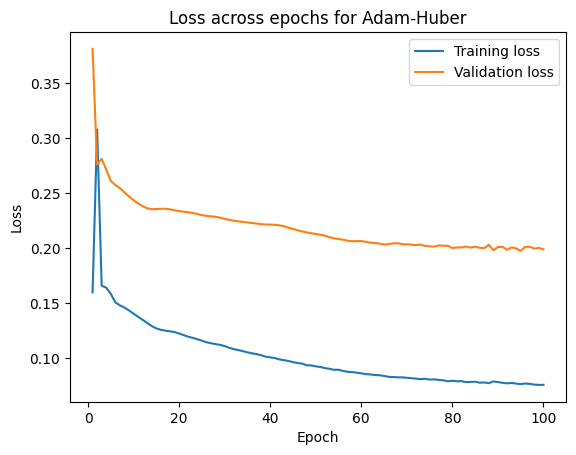

In [ ]:
adam250Model.get_loss_graph("for Adam-Huber")

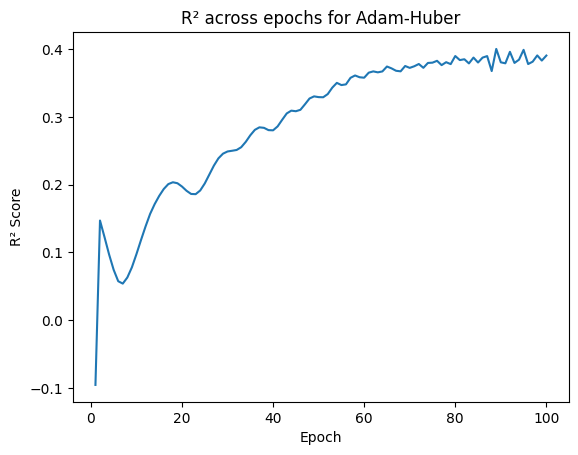

In [ ]:
adam250Model.get_r2_graph("for Adam-Huber")

In [ ]:
trn1, valid1, r21 = adam250Model.metrics()

metrics = {"train":trn1, "valid":valid1, "r2":r21}
metricsDF = pd.DataFrame(metrics)
metricsDF.to_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/results/AdamHuber.csv")

### Plot experiments

In [ ]:
SgdMSE = pd.read_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/results/sdgMse.csv")
SgdHuber = pd.read_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/results/sdgHuber.csv")
AdamMSE = pd.read_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/results/AdamMSE.csv")
AdamHuber = pd.read_csv("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/results/AdamHuber.csv")

In [ ]:
(v1, v2, v3) = SgdMSE[cols].values.squeeze()

ValueError: too many values to unpack (expected 3)

In [ ]:
t1, v1, r1 = SgdMSE['train'].to_numpy(), SgdMSE['valid'].to_numpy(), SgdMSE['r2'].to_numpy()
t2, v2, r2 = SgdHuber['train'].to_numpy(), SgdHuber['valid'].to_numpy(), SgdHuber['r2'].to_numpy()
t3, v3, r3 = AdamMSE['train'].to_numpy(), AdamMSE['valid'].to_numpy(), AdamMSE['r2'].to_numpy()
t4, v4, r4 = AdamHuber['train'].to_numpy(), AdamHuber['valid'].to_numpy(), AdamHuber['r2'].to_numpy()


In [ ]:
r2s= [r1,r2,r3,r4]

for i, r in enumerate(r2s):
    max_val = round(r.max(), 3)
    best_epoch = r.argmax() + 1

    print(max_val, best_epoch)

0.366 82
0.231 100
0.374 32
0.401 89


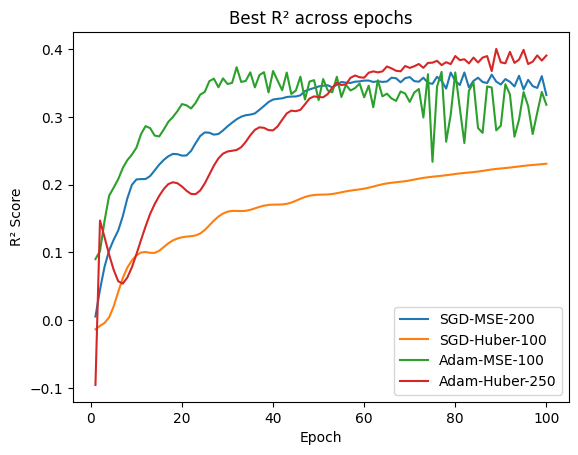

In [ ]:
fig, ax = plt.subplots()
ax.set_title("Best R\u00b2 across epochs")
# ax.grid(True)
ax.set_ylabel("R\u00b2 Score")
ax.set_xlabel("Epoch")
ax.plot(range(1, 101), r1, label="SGD-MSE-200")
ax.plot(range(1, 101), r2, label="SGD-Huber-100")
ax.plot(range(1, 101), r3, label="Adam-MSE-100")
ax.plot(range(1, 101), r4, label="Adam-Huber-250")
ax.legend()

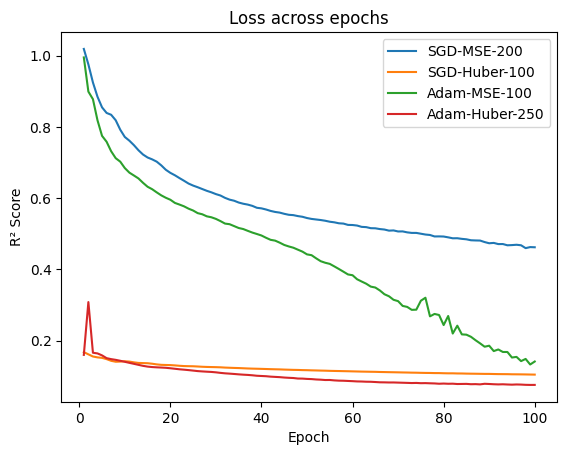

In [ ]:
fig, ax = plt.subplots()
ax.set_title("Loss across epochs")
# ax.grid(True)
ax.set_ylabel("R\u00b2 Score")
ax.set_xlabel("Epoch")
ax.plot(range(1, 101), t1, label="SGD-MSE-200")
ax.plot(range(1, 101), t2, label="SGD-Huber-100")
ax.plot(range(1, 101), t3, label="Adam-MSE-100")
ax.plot(range(1, 101), t4, label="Adam-Huber-250")
ax.legend()

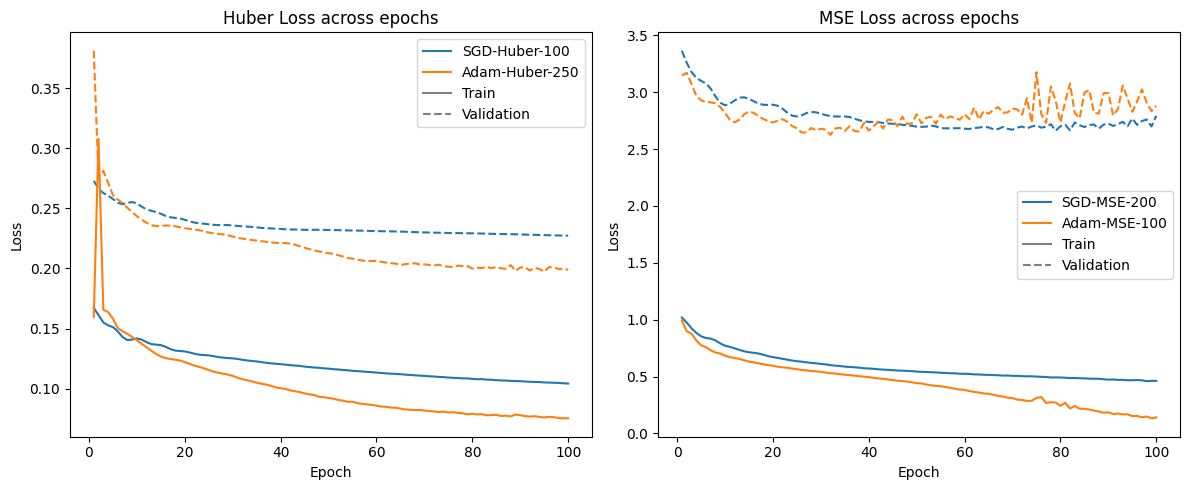

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

style_handles = [
    Line2D([0], [0], color="gray", linestyle="-", label="Train"),
    Line2D([0], [0], color="gray", linestyle="--", label="Validation"),
]

# MSE
ax2.set_title("MSE Loss across epochs")
ax2.set_ylabel("Loss")
ax2.set_xlabel("Epoch")

(p3,) = ax2.plot(range(1, 101), t1, linestyle="-", label="SGD-MSE-200")
ax2.plot(range(1, 101), v1, linestyle="--", color=p3.get_color())
(p4,) = ax2.plot(range(1, 101), t3, linestyle="-", label="Adam-MSE-100")
ax2.plot(range(1, 101), v3, linestyle="--", color=p4.get_color())

ax2.legend(handles=[p3, p4] + style_handles, loc="center right")

# Huber
ax1.set_title("Huber Loss across epochs")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")

(p1,) = ax1.plot(range(1, 101), t2, linestyle="-", label="SGD-Huber-100")
ax1.plot(range(1, 101), v2, linestyle="--", color=p1.get_color())
(p2,) = ax1.plot(range(1, 101), t4, linestyle="-", label="Adam-Huber-250")
ax1.plot(range(1, 101), v4, linestyle="--", color=p2.get_color())

ax1.legend(handles=[p1, p2] + style_handles, loc="upper right")

plt.tight_layout()
plt.show()

### Test run

#### Adam50 with LR 0.01

In [ ]:
adam50 = LinearRegression(5, 2, 50) # 5 features output x,y

adam50Model = CoordCropModel(
    model=adam50,
    loss=torch.nn.HuberLoss(),
    opt_class=torch.optim.Adam,
    dataloaders=dataloader_dict,
    lr=0.01
    )
adam50Model.fit(100)

Epoch 1 - Train Loss: 0.1798 - Valid Loss: 0.2620 - R2: 0.0164
Epoch 2 - Train Loss: 0.1565 - Valid Loss: 0.2564 - R2: 0.0263
Epoch 3 - Train Loss: 0.1484 - Valid Loss: 0.2551 - R2: 0.0396
Epoch 4 - Train Loss: 0.1452 - Valid Loss: 0.2537 - R2: 0.0590
Epoch 5 - Train Loss: 0.1433 - Valid Loss: 0.2525 - R2: 0.0780
Epoch 6 - Train Loss: 0.1410 - Valid Loss: 0.2521 - R2: 0.0911
Epoch 7 - Train Loss: 0.1401 - Valid Loss: 0.2497 - R2: 0.0996
Epoch 8 - Train Loss: 0.1387 - Valid Loss: 0.2457 - R2: 0.1044
Epoch 9 - Train Loss: 0.1363 - Valid Loss: 0.2423 - R2: 0.1058
Epoch 10 - Train Loss: 0.1345 - Valid Loss: 0.2408 - R2: 0.1051
Epoch 11 - Train Loss: 0.1338 - Valid Loss: 0.2402 - R2: 0.1074
Epoch 12 - Train Loss: 0.1329 - Valid Loss: 0.2391 - R2: 0.1151
Epoch 13 - Train Loss: 0.1311 - Valid Loss: 0.2381 - R2: 0.1271
Epoch 14 - Train Loss: 0.1289 - Valid Loss: 0.2375 - R2: 0.1410
Epoch 15 - Train Loss: 0.1273 - Valid Loss: 0.2371 - R2: 0.1545
Epoch 16 - Train Loss: 0.1262 - Valid Loss: 0.236

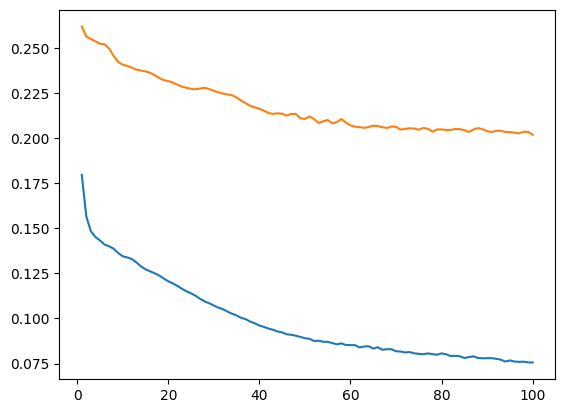

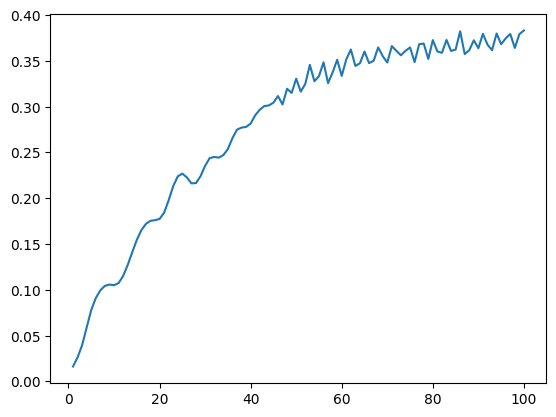

(None, None)

In [ ]:
adam50Model.get_loss_graph(), adam50Model.get_r2_graph()

## Final Model

In [ ]:
adam250Overfit = LinearRegression(5, 2, 250) # 5 features output x,y

adam250Overfit = CoordCropModel(
    model=adam250Overfit,
    loss=torch.nn.HuberLoss(),
    opt_class=torch.optim.Adam,
    dataloaders=dataloader_dict,
    lr=0.005
    )
adam250Overfit.fit(150)

Epoch 1 - Train Loss: 0.1741 - Valid Loss: 0.4898 - R2: -0.1370
Epoch 2 - Train Loss: 0.4037 - Valid Loss: 0.2643 - R2: 0.0782
Epoch 3 - Train Loss: 0.1599 - Valid Loss: 0.2624 - R2: 0.1405
Epoch 4 - Train Loss: 0.1560 - Valid Loss: 0.2766 - R2: 0.1445
Epoch 5 - Train Loss: 0.1726 - Valid Loss: 0.2655 - R2: 0.1342
Epoch 6 - Train Loss: 0.1607 - Valid Loss: 0.2565 - R2: 0.1191
Epoch 7 - Train Loss: 0.1494 - Valid Loss: 0.2528 - R2: 0.1082
Epoch 8 - Train Loss: 0.1431 - Valid Loss: 0.2514 - R2: 0.1042
Epoch 9 - Train Loss: 0.1396 - Valid Loss: 0.2502 - R2: 0.1083
Epoch 10 - Train Loss: 0.1366 - Valid Loss: 0.2486 - R2: 0.1185
Epoch 11 - Train Loss: 0.1335 - Valid Loss: 0.2467 - R2: 0.1315
Epoch 12 - Train Loss: 0.1305 - Valid Loss: 0.2447 - R2: 0.1454
Epoch 13 - Train Loss: 0.1276 - Valid Loss: 0.2430 - R2: 0.1588
Epoch 14 - Train Loss: 0.1253 - Valid Loss: 0.2414 - R2: 0.1715
Epoch 15 - Train Loss: 0.1234 - Valid Loss: 0.2396 - R2: 0.1850
Epoch 16 - Train Loss: 0.1217 - Valid Loss: 0.23

(None, None)

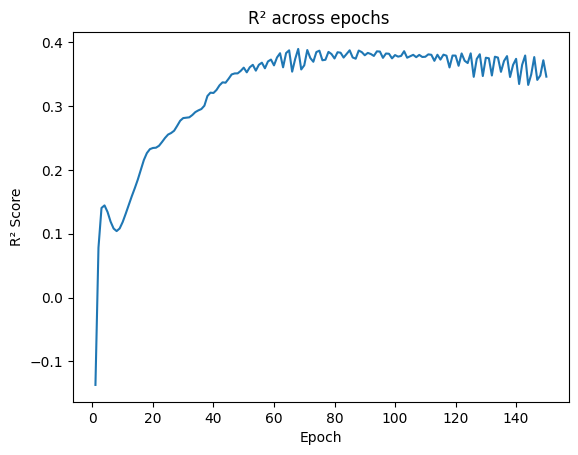

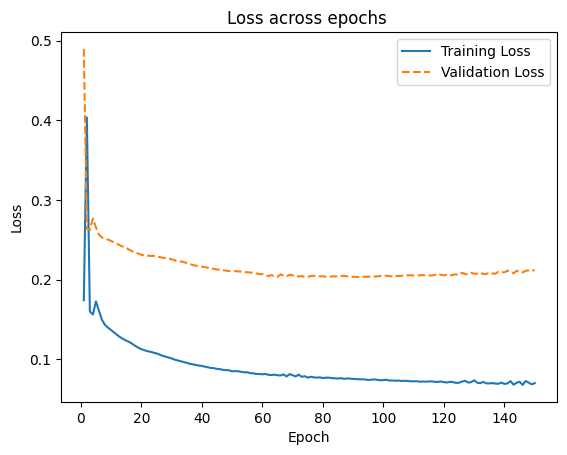

In [ ]:
adam250Overfit.get_r2_graph(), adam250Overfit.get_loss_graph()

In [ ]:
min(adam250Overfit.valid_loss)

0.20321416854858398

In [ ]:
adam250Overfit.valid_loss.index(min(adam250Overfit.valid_loss))

90

In [ ]:
adam250Final = LinearRegression(5, 2, 250) # 5 features output x,y

adam250FModel = CoordCropModel(
    model=adam250Final,
    loss=torch.nn.HuberLoss(),
    opt_class=torch.optim.Adam,
    dataloaders=dataloader_dict,
    lr=0.005
    )
adam250FModel.fit(80)

Epoch 1 - Train Loss: 0.1617 - Valid Loss: 0.3109 - R2: 0.0464
Epoch 2 - Train Loss: 0.2243 - Valid Loss: 0.2817 - R2: 0.1528
Epoch 3 - Train Loss: 0.1652 - Valid Loss: 0.2594 - R2: 0.1250
Epoch 4 - Train Loss: 0.1457 - Valid Loss: 0.2511 - R2: 0.0786
Epoch 5 - Train Loss: 0.1410 - Valid Loss: 0.2538 - R2: 0.0398
Epoch 6 - Train Loss: 0.1456 - Valid Loss: 0.2550 - R2: 0.0287
Epoch 7 - Train Loss: 0.1474 - Valid Loss: 0.2521 - R2: 0.0411
Epoch 8 - Train Loss: 0.1434 - Valid Loss: 0.2472 - R2: 0.0673
Epoch 9 - Train Loss: 0.1372 - Valid Loss: 0.2430 - R2: 0.0982
Epoch 10 - Train Loss: 0.1317 - Valid Loss: 0.2409 - R2: 0.1286
Epoch 11 - Train Loss: 0.1285 - Valid Loss: 0.2411 - R2: 0.1550
Epoch 12 - Train Loss: 0.1280 - Valid Loss: 0.2418 - R2: 0.1747
Epoch 13 - Train Loss: 0.1287 - Valid Loss: 0.2409 - R2: 0.1856
Epoch 14 - Train Loss: 0.1282 - Valid Loss: 0.2382 - R2: 0.1885
Epoch 15 - Train Loss: 0.1260 - Valid Loss: 0.2354 - R2: 0.1852
Epoch 16 - Train Loss: 0.1236 - Valid Loss: 0.233

In [ ]:
adam250FModel.r2[-1]

0.3709165155887604

(None, None)

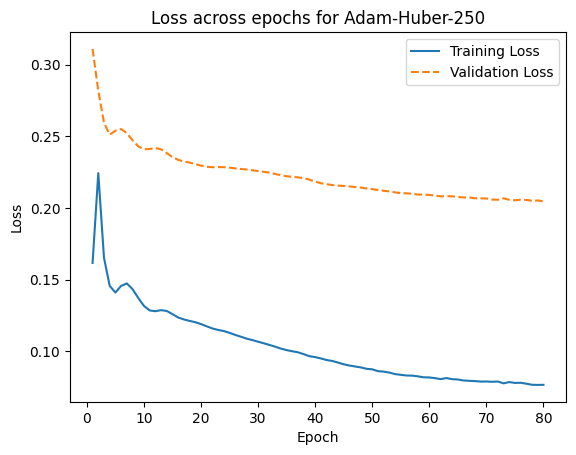

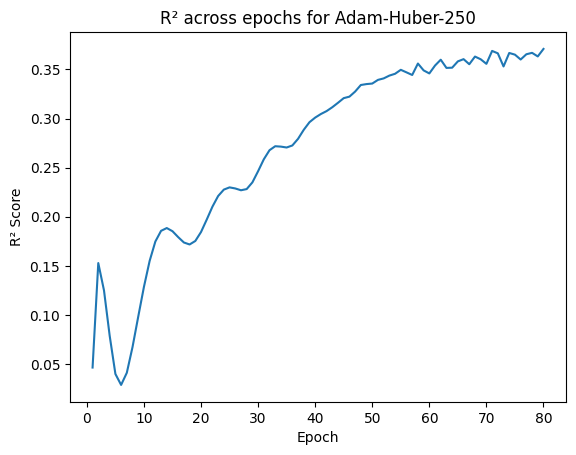

In [ ]:
adam250FModel.get_loss_graph("for Adam-Huber-250"), adam250FModel.get_r2_graph("for Adam-Huber-250")

In [ ]:
torch.save(adam250Model.model.state_dict(), "/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/LoadRegressionAdam250.pth")

Train test

In [49]:
adam250 = LinearRegression(5, 2, 250) # 5 features output x,y

adam250Model = CoordCropModel(
    model=adam250,
    loss=torch.nn.HuberLoss(),
    opt_class=torch.optim.Adam,
    dataloaders=dataloader_dict,
    lr=0.005
    )
adam250Model.fit(80)

Epoch 1 - Train Loss: 0.1625 - Valid Loss: 0.3017 - R2: 0.1140
Epoch 2 - Train Loss: 0.1967 - Valid Loss: 0.2639 - R2: 0.0803
Epoch 3 - Train Loss: 0.1617 - Valid Loss: 0.2456 - R2: 0.0769
Epoch 4 - Train Loss: 0.1457 - Valid Loss: 0.2495 - R2: 0.0689
Epoch 5 - Train Loss: 0.1478 - Valid Loss: 0.2465 - R2: 0.0810
Epoch 6 - Train Loss: 0.1418 - Valid Loss: 0.2412 - R2: 0.1021
Epoch 7 - Train Loss: 0.1364 - Valid Loss: 0.2384 - R2: 0.1225
Epoch 8 - Train Loss: 0.1329 - Valid Loss: 0.2382 - R2: 0.1418
Epoch 9 - Train Loss: 0.1310 - Valid Loss: 0.2389 - R2: 0.1597
Epoch 10 - Train Loss: 0.1295 - Valid Loss: 0.2389 - R2: 0.1736
Epoch 11 - Train Loss: 0.1276 - Valid Loss: 0.2374 - R2: 0.1823
Epoch 12 - Train Loss: 0.1252 - Valid Loss: 0.2348 - R2: 0.1864
Epoch 13 - Train Loss: 0.1226 - Valid Loss: 0.2322 - R2: 0.1860
Epoch 14 - Train Loss: 0.1202 - Valid Loss: 0.2305 - R2: 0.1835
Epoch 15 - Train Loss: 0.1189 - Valid Loss: 0.2296 - R2: 0.1839
Epoch 16 - Train Loss: 0.1180 - Valid Loss: 0.228

In [51]:
adam250Model.model

LinearRegression(
  (linear): Sequential(
    (0): Linear(in_features=5, out_features=250, bias=True)
    (1): ReLU()
    (2): Linear(in_features=250, out_features=250, bias=True)
    (3): ReLU()
    (4): Linear(in_features=250, out_features=2, bias=True)
  )
)

In [52]:
torch.save(adam250Model.model.state_dict(), "/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/LoadRegressionAdam250.pth")